## Examen Practico - Tercer Parcial
<img src="img/Recurso.jpeg" width="700">

**Nombre:** *Steven Chuiza* <br>
**Fecha:** *14/6/2026* <br>

#### 0) Cargar una de las imágenes histológicas

In [1]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

In [2]:
# Importamos las librerias a utilizar en todo el programa
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops # Para descriptores de textura
from skimage.measure import regionprops, label # Para descriptores de forma
from skimage import io

In [3]:
# 1: Utilizamos la libreria skimage.io, nos permitira leer las imagenens a analizar en formato RGB
img_s = io.imread ('histo_1.jpg')
img_c = io.imread ('histo_2.jpg')

In [4]:
# 2: Realizamos la normalizacion a amabas imagenes para que los pixeles se encuentren en rango [0, 1]
# Las imagenes digitales contienen valores de 0 a 255, lo cual vamos a dividir para normalizar
img_s_norm = img_s / 255.0
img_c_norm = img_c / 255.0

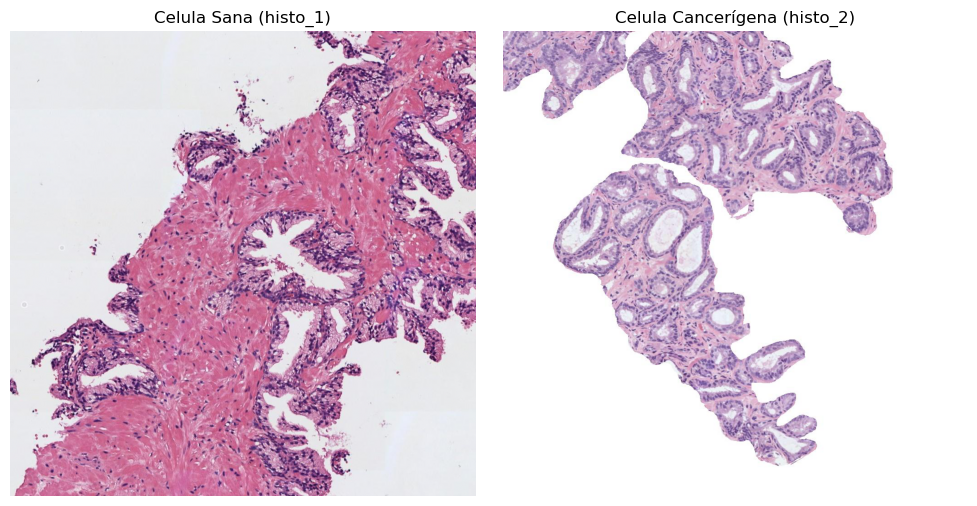

In [5]:
# 3: Visualizamos las imagenes ya normalizadas 
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img_s_norm)
ax[0].set_title('Celula Sana (histo_1)')
ax[0].axis('off')

ax[1].imshow(img_c_norm)
ax[1].set_title('Celula Cancerígena (histo_2)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [6]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

In [7]:
# 1: Extreamos los componentes magenta SIENDO ( M = 1 - G ) 
# El canal verde corresponde al indice 1 dentro de la matriz RGB (0:R, 1:G, 2:G )
mag_s = 1.0 - img_s_norm[:, :, 1]
mag_c = 1.0 - img_c_norm[:, :, 1]

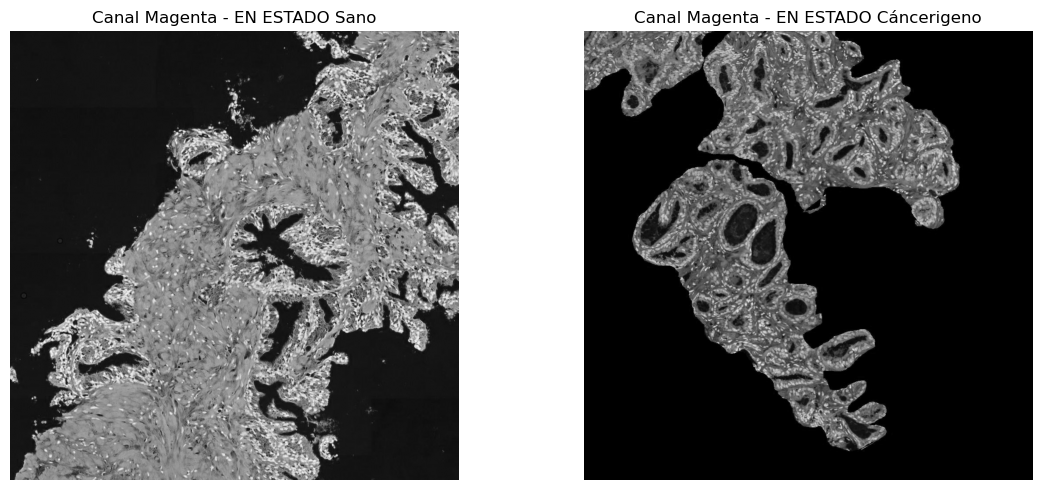

In [8]:
# 2: Visualizamos ambas imagenes de cada magenta
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Se utiliza cmap='gray' para visualizar la intensidad del canal
ax[0].imshow(mag_s, cmap='gray')
ax[0].set_title('Canal Magenta - EN ESTADO Sano')
ax[0].axis('off')

ax[1].imshow(mag_c, cmap='gray')
ax[1].set_title('Canal Magenta - EN ESTADO Cáncerigeno')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [9]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

In [10]:
# 1: Convertimos las imagenens del anterior canal al rango de [0-255] en el formato unit8
mag_s_unit8 = (mag_s * 255).astype(np.uint8)
mag_c_unit8 = (mag_c * 255).astype(np.uint8)

In [11]:
# 2: Aplicacmos el filtro gaussiano del tamaño 5x5
# EL 0 va a ser el indicacor que OpenCV calcule automaticamente la desviacion estandar (sigma)
blur_s = cv2.GaussianBlur(mag_s_unit8, (5,5),0)
blur_c = cv2.GaussianBlur(mag_c_unit8, (5,5),0)

In [12]:
# 3: Aplicamos el metodo de Otsu
# Utilizamos el THRESH_BINARY_INV con la finalidad de que el fondo (oscuro) pase a ser 1 mientras que la celula (clara) pase a ser 0
# El valor 1 va a ser nuestro valor maximo que va a tomar los pixeles umbralizados
_, mask_s = cv2.threshold(blur_s, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, mask_c = cv2.threshold(blur_c, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

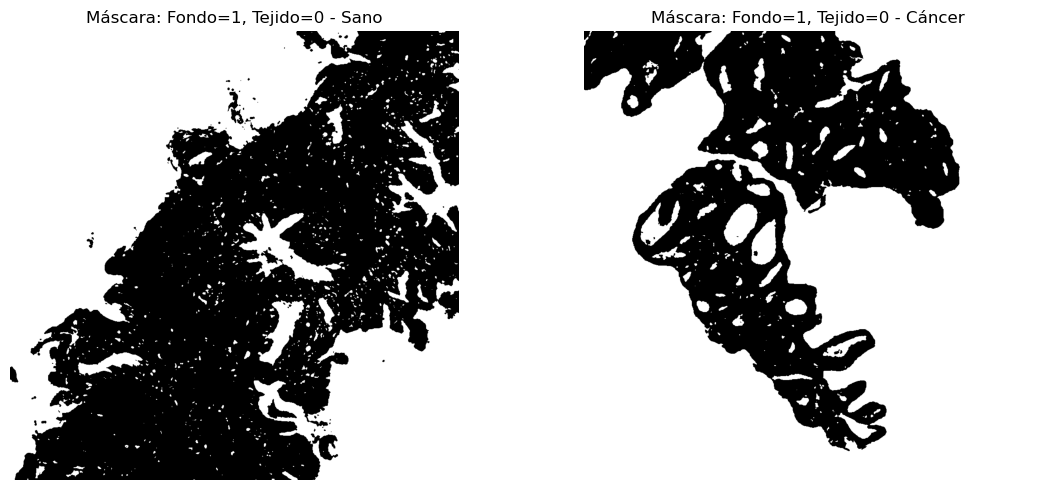

In [13]:
# 4: Visualizamos la mascara resultante
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Usamos vmax=1 para que matplotlib inerprete que el color blanco absoluto es 1 y el negro es 0
ax[0].imshow(mask_s, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Máscara: Fondo=1, Tejido=0 - Sano')
ax[0].axis('off')

ax[1].imshow(mask_c, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Máscara: Fondo=1, Tejido=0 - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [14]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

In [15]:
from skimage.morphology import remove_small_objects

# 1: Convertimos las mascaras a tipo booleano lo cual es requerido por la funcion
mask_s_bool = mask_s.astype(bool)
mask_c_bool = mask_c.astype(bool)

In [16]:
# 2: Eliminamos los objetos pequeños (puntos) o areas menores a 300 pixeles
mask_s_clean = remove_small_objects(mask_s_bool, min_size=300)
mask_c_clean = remove_small_objects(mask_c_bool, min_size=300)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18576\4067965805.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_s_clean = remove_small_objects(mask_s_bool, min_size=300)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18576\4067965805.py:3: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_c_clean = remove_sma

In [17]:
# 3: Convertimos de nuevo a enteros de 0 y 1 para lograr visualizar y realizar futuros calculos
mask_s_clean = mask_s_clean.astype(np.uint8)
mask_c_clean = mask_c_clean.astype(np.uint8)

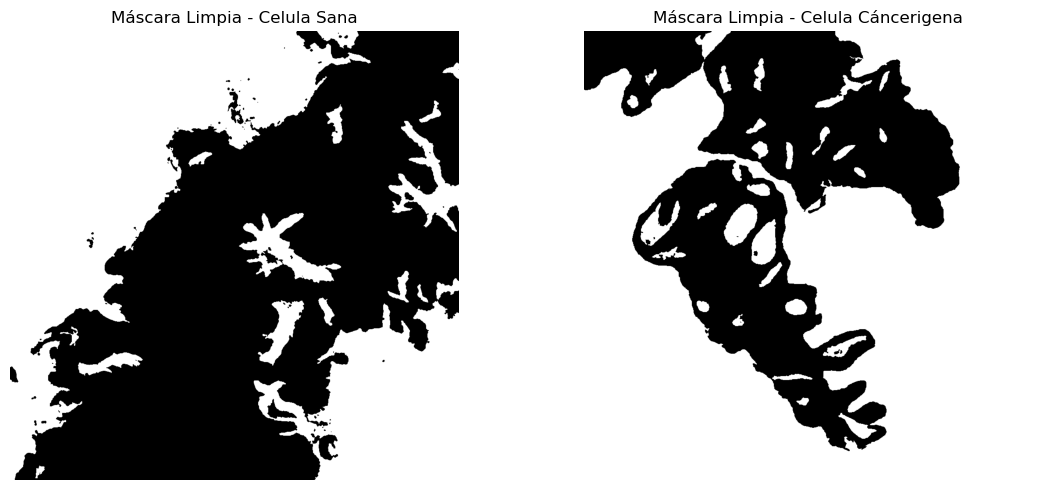

In [18]:
# 4: Visualizamos la mascara resultante
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(mask_s_clean, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Máscara Limpia - Celula Sana')
ax[0].axis('off')

ax[1].imshow(mask_c_clean, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Máscara Limpia - Celula Cáncerigena')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [19]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

In [20]:
# Desarrollamos la funcion para encontrar semillas
def encontrar_semillas_lumen(mascara):
    etiquetas = label(mascara)
    propiedades = regionprops(etiquetas)

    regiones_arregladas = sorted(propiedades, key=lambda x: x.area, reverse=True)

    semillas = []
    #Omitimos el fondo (indice0)
    for reg in regiones_arregladas[1:]:
        # Tomamos la coordenada exacta del primer pixel de la region (y,x)
        y,x = reg.coords[0]
        semillas.append((int(x), int(y)))

    return semillas

In [21]:
# 1: Obtenemos todas las semillas exactas
semi_s = encontrar_semillas_lumen(mask_s_clean)
semi_c = encontrar_semillas_lumen(mask_c_clean)

In [22]:
# 2: Iniciamos los lienzos completamnentes negros (0s)
l_s = np.zeros_like(mask_s_clean)
l_c = np.zeros_like(mask_c_clean)

# copias del trabajo 
mask_s_flood = mask_s_clean.copy()
mask_c_flood = mask_c_clean.copy()

In [23]:
# 3: Aplicamos floodFill para el tejido sano
for seed in semi_s:
    cv2.floodFill(mask_s_flood, None, seed, 255)
    l_s[mask_s_flood == 255] = 1
    mask_s_flood[mask_s_flood == 255] = 0

In [24]:
# 4: Aplicamos floodFill para el tejido con cancer
for seed in semi_c:
    cv2.floodFill(mask_c_flood, None, seed, 255)
    l_c[mask_c_flood == 255] = 1
    mask_c_flood[mask_c_flood == 255] = 0

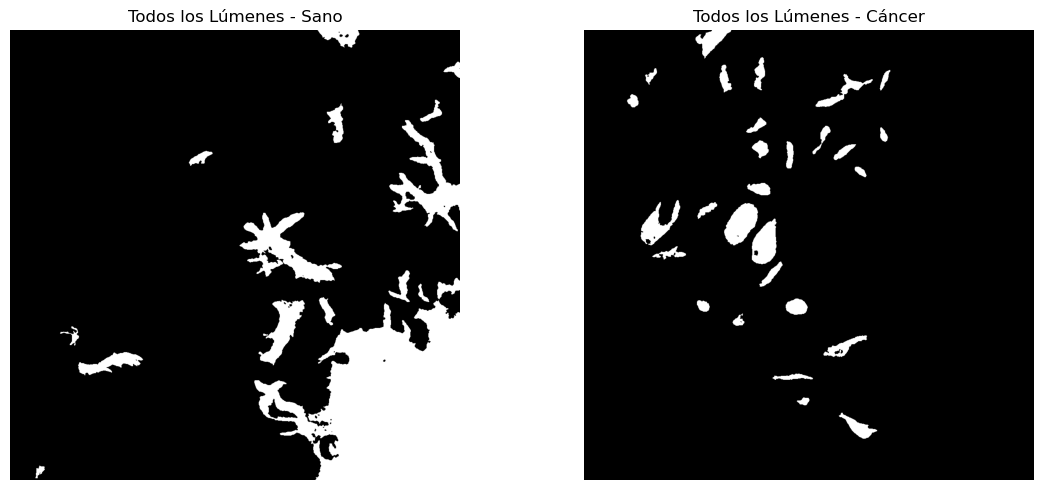

In [25]:
# 5. Visualizamos el resultado final
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(l_s, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Todos los Lúmenes - Sano')
ax[0].axis('off')

ax[1].imshow(l_c, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Todos los Lúmenes - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 5) Rellenar los objetos de los lúmenes

In [26]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

In [27]:
from scipy.ndimage import binary_fill_holes

# 1: Aplicamos la libreria binary_fill_holes
# Esta funcion nos va a devolver una matriz booleana (True/Falce), para despues pasar a unit8(1/0)
l_s_filled = binary_fill_holes(l_s).astype(np.uint8)
l_c_filled = binary_fill_holes(l_c).astype(np.uint8)

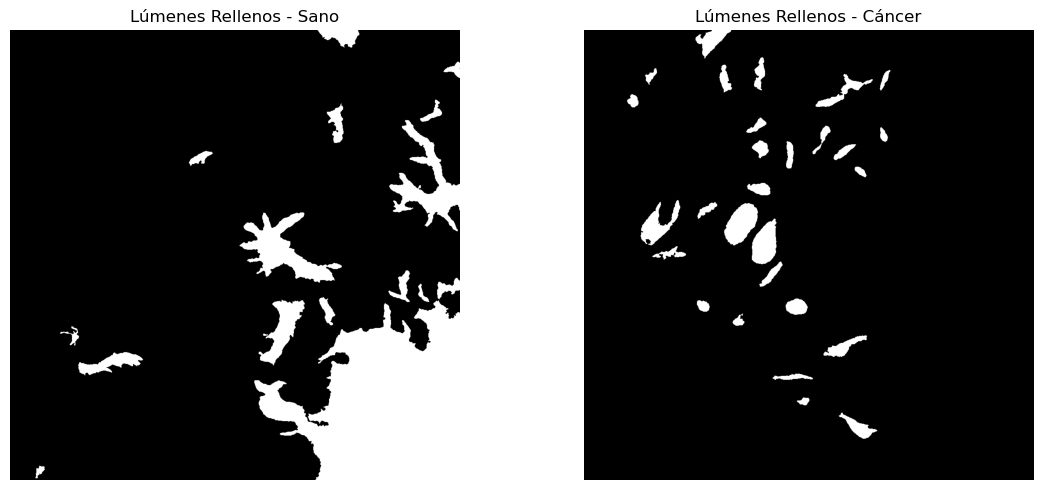

In [28]:
# 2. Visualizar la máscara resultante
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(l_s_filled, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Lúmenes Rellenos - Sano')
ax[0].axis('off')

ax[1].imshow(l_c_filled, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Lúmenes Rellenos - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [29]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

In [30]:
# 1: Encontramos los contornos Usando OpenCV
# cv2.RETR_EXTERNAL: Solo recupera los contornos externos (ideal porque ya rellenamos los huecos)
# cv2.CHAIN_APPROX_SIMPLE: Optimiza la memoria guardando solo los puntos clave del contorno
contornos_s,_ = cv2.findContours(l_s_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_c,_ = cv2.findContours(l_c_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [31]:
# 2: Realizamos una copia de las imagenes originales "antes de la normalizacion" con la finalidad de no dañar los datos originales
# Como usamos skimage.io en el paso 0, img_s e img_c las cuales ya se encuentran el formato RGB [0-255]
img_s_c = img_s.copy()
img_c_c = img_c.copy()

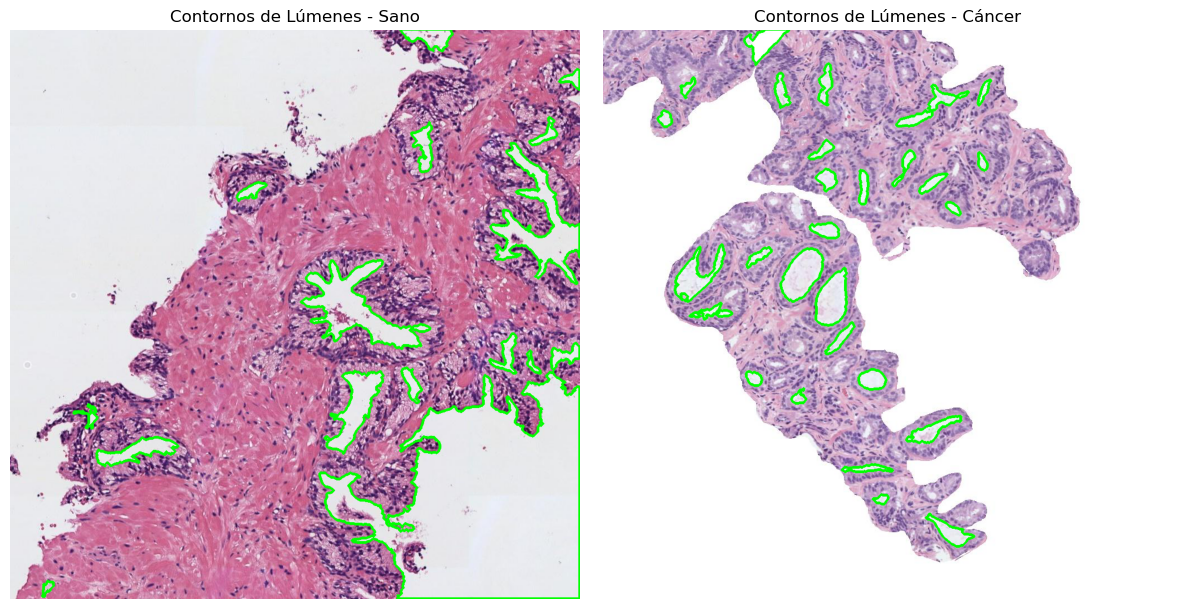

In [32]:
# 3. Dibujar los contornos
# El flag -1 indica que dibuje TODOS los contornos de la lista. 
# (0, 255, 0) es el color Verde en RGB. thickness=3 lo hace perfectamente visible.
cv2.drawContours(img_s_c, contornos_s, -1, (0, 255, 0), thickness=3)
cv2.drawContours(img_c_c, contornos_c, -1, (0, 255, 0), thickness=3)

# 4. Visualizar los resultados
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_s_c)
ax[0].set_title('Contornos de Lúmenes - Sano')
ax[0].axis('off')

ax[1].imshow(img_c_c)
ax[1].set_title('Contornos de Lúmenes - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 7) Identificar y cropear el lumen más grande

In [33]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

In [34]:
# Función ajustada para elegir qué número de lumen queremos (1º, 2º, 3º más grande...)
def cropear_lumen_n(imagen_rgb, mascara_rellena, n_lumen=1):
    etiquetas = label(mascara_rellena)
    propiedades = regionprops(etiquetas)
    
    # Ordenamos las regiones por área de MAYOR a MENOR
    regiones_ordenadas = sorted(propiedades, key=lambda r: r.area, reverse=True)
    
    # Seleccionamos el lumen deseado (restando 1 porque los índices en Python empiezan en 0)
    region_objetivo = regiones_ordenadas[n_lumen - 1]
    
    # Extraemos las coordenadas de la caja delimitadora
    min_row, min_col, max_row, max_col = region_objetivo.bbox
    
    # Recortamos la imagen
    imagen_recortada = imagen_rgb[min_row:max_row, min_col:max_col]
    
    return imagen_recortada

In [35]:
# 1. Para el Sano pedimos el 2do más grande (n_lumen=2). Para el Cáncer pedimos el 1ro (n_lumen=1).
lumen_s_crop = cropear_lumen_n(img_s, l_s_filled, n_lumen=2)
lumen_c_crop = cropear_lumen_n(img_c, l_c_filled, n_lumen=1)

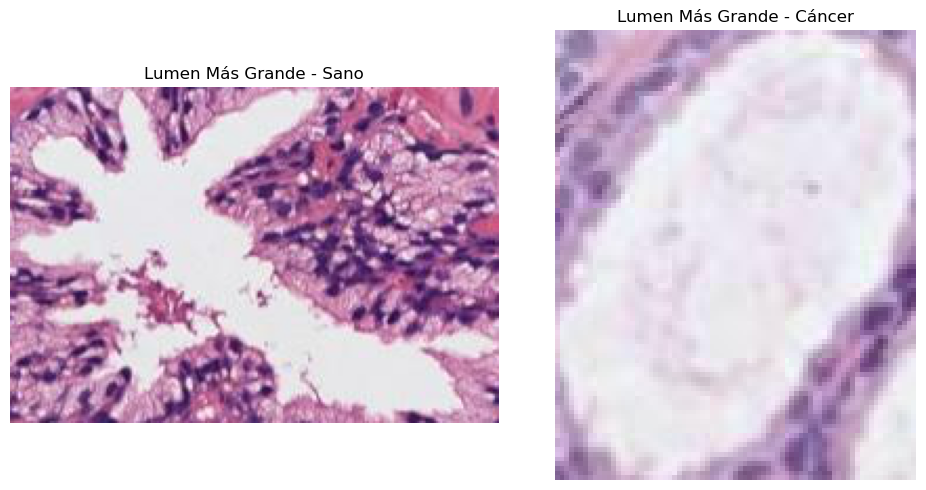

In [36]:
# 2. Visualizar los recortes resultantes
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(lumen_s_crop)
ax[0].set_title('Lumen Más Grande - Sano')
ax[0].axis('off')

ax[1].imshow(lumen_c_crop)
ax[1].set_title('Lumen Más Grande - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [37]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [38]:
# Función para extraer las 13 características solicitadas
def extraer_13_caracteristicas(mascara_rellena, n_lumen=1):
    etiquetas = label(mascara_rellena)
    propiedades = regionprops(etiquetas)
    
    # Ordenamos de mayor a menor área para seleccionar el lumen correcto
    regiones_ordenadas = sorted(propiedades, key=lambda r: r.area, reverse=True)
    region = regiones_ordenadas[n_lumen - 1]
    
    # Extraemos características de regionprops de forma segura para compatibilidad de versiones
    area = region.area
    bbox_area = region.bbox_area
    convex_area = region.convex_area
    eccentricity = region.eccentricity
    eq_diameter = getattr(region, 'equivalent_diameter_area', getattr(region, 'equivalent_diameter', 0))
    extent = region.extent
    feret = getattr(region, 'feret_diameter_max', 0)
    major_axis = getattr(region, 'axis_major_length', getattr(region, 'major_axis_length', 0))
    minor_axis = getattr(region, 'axis_minor_length', getattr(region, 'minor_axis_length', 0))
    orientation = region.orientation
    perimeter = region.perimeter
    solidity = region.solidity
    
    # Calculamos la Compacidad manualmente
    compacidad = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    
    # Armamos un diccionario con el redondeo exacto a 4 decimales
    caracteristicas = {
        "1) Área": round(area, 4),
        "2) Área de la bounding box": round(bbox_area, 4),
        "3) Área convexa": round(convex_area, 4),
        "4) Excentricidad": round(eccentricity, 4),
        "5) Diámetro equivalente": round(eq_diameter, 4),
        "6) Extensión": round(extent, 4),
        "7) Diámetro Feret": round(feret, 4),
        "8) Longitud del eje mayor": round(major_axis, 4),
        "9) Longitud del eje menor": round(minor_axis, 4),
        "10) Orientación": round(orientation, 4),
        "11) Perímetro": round(perimeter, 4),
        "12) Solidez": round(solidity, 4),
        "13) Compacidad": round(compacidad, 4)
    }
    
    return caracteristicas

In [41]:
# 1. Aplicamos la función usando el índice correcto (2do lumen sano, 1er lumen cáncer)
caracteristicas_sano = extraer_13_caracteristicas(l_s_filled, n_lumen=2)
caracteristicas_cancer = extraer_13_caracteristicas(l_c_filled, n_lumen=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18576\905947475.py:12: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  bbox_area = region.bbox_area
C:\Users\Admin\AppData\Local\Temp\ipykernel_18576\905947475.py:13: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  convex_area = region.convex_area
C:\Users\Admin\AppData\Local\Temp\ipykernel_18576\905947475.py:15: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  eq_diameter = getattr(region, 'equivalent_diameter_area', getattr(region, 'equivalent_diameter', 0))
C:\Users\Admin\AppData\Local\Temp\ipykernel_18576\905947475.py:18: FutureWarning: `RegionProperties.major_axis_leng

In [42]:
# 2. Mostramos los datos en una tabla comparativa con Pandas
df_caracteristicas = pd.DataFrame({
    'Tejido Sano (Lumen Objetivo)': caracteristicas_sano,
    'Tejido Cáncer (Lumen Objetivo)': caracteristicas_cancer
})

print("--- 13 Características Geométricas Extraídas ---")
display(df_caracteristicas) # display() formatea la tabla visualmente en Jupyter

--- 13 Características Geométricas Extraídas ---


,Tejido Sano (Lumen Objetivo),Tejido Cáncer (Lumen Objetivo)
1) Área,13314.0000,4696.0000
2) Área de la bounding box,37280.0000,7392.0000
3) Área convexa,27239.0000,4882.0000
4) Excentricidad,0.8449,0.8376
5) Diámetro equivalente,130.1995,77.3249
6) Extensión,0.3571,0.6353
7) Diámetro Feret,242.5387,104.3168
8) Longitud del eje mayor,231.1763,104.8865
9) Longitud del eje menor,123.6775,57.2945
10) Orientación,0.9957,-0.5626


Repositorio de github: https://github.com/tiven29/Fundamentos_Machine_Learning